<a href="https://colab.research.google.com/github/GameofCodeZ/classical-cryptography-toolkit/blob/main/classical_cryptography_toolkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classical Cryptography Toolkit

This project implements several classical encryption algorithms and basic cryptanalysis techniques.

Algorithms included:
- Caesar Cipher
- Vigenère Cipher
- XOR Cipher
- Frequency Analysis

The goal is to understand how classical encryption works and how statistical properties of text can help analyze encrypted messages.

In [1]:
import string
import matplotlib.pyplot as plt
from collections import Counter

## Caesar Cipher

The Caesar cipher shifts each letter in the plaintext by a fixed number of positions in the alphabet.
For example, with a shift of 3:

A → D
B → E
C → F

In [2]:
alphabet = string.ascii_uppercase

def caesar_encrypt(text, shift):
    result = ""
    text = text.upper()
    for char in text:
        if char in alphabet:
            index = alphabet.index(char)
            new_index = (index + shift) % 26
            result += alphabet[new_index]
        else:
            result += char
    return result

def caesar_decrypt(text, shift):
    return caesar_encrypt(text, -shift)

In [3]:
plaintext = "CRYPTOGRAPHY IS FUN"
key = 3

cipher = caesar_encrypt(plaintext, key)

print("Plaintext:", plaintext)
print("Encrypted:", cipher)
print("Decrypted:", caesar_decrypt(cipher, key))

Plaintext: CRYPTOGRAPHY IS FUN
Encrypted: FUBSWRJUDSKB LV IXQ
Decrypted: CRYPTOGRAPHY IS FUN


## Vigenère Cipher

The Vigenère cipher uses a keyword to determine the shift for each letter.
This makes it more secure than the Caesar cipher because different letters may be shifted by different amounts.

In [4]:
def vigenere_encrypt(text, key):
    text = text.upper()
    key = key.upper()
    result = ""
    key_index = 0

    for char in text:
        if char in alphabet:
            shift = alphabet.index(key[key_index % len(key)])
            index = alphabet.index(char)
            new_index = (index + shift) % 26
            result += alphabet[new_index]
            key_index += 1
        else:
            result += char

    return result


def vigenere_decrypt(text, key):
    text = text.upper()
    key = key.upper()
    result = ""
    key_index = 0

    for char in text:
        if char in alphabet:
            shift = alphabet.index(key[key_index % len(key)])
            index = alphabet.index(char)
            new_index = (index - shift) % 26
            result += alphabet[new_index]
            key_index += 1
        else:
            result += char

    return result

In [5]:
plaintext = "CRYPTOGRAPHY IS INTERESTING"
key = "KEY"

cipher = vigenere_encrypt(plaintext, key)

print("Plaintext:", plaintext)
print("Encrypted:", cipher)
print("Decrypted:", vigenere_decrypt(cipher, key))

Plaintext: CRYPTOGRAPHY IS INTERESTING
Encrypted: MVWZXMQVYZLW SW GXXCBIQDMLQ
Decrypted: CRYPTOGRAPHY IS INTERESTING


## XOR Cipher

The XOR cipher encrypts data by applying the XOR operation between each character and a key.

In [6]:
def xor_encrypt(text, key):
    encrypted = ""
    for char in text:
        encrypted += chr(ord(char) ^ key)
    return encrypted

def xor_decrypt(cipher, key):
    return xor_encrypt(cipher, key)

In [7]:
plaintext = "HELLO CRYPTO"
key = 23

cipher = xor_encrypt(plaintext, key)

print("Encrypted:", cipher)
print("Decrypted:", xor_decrypt(cipher, key))

Encrypted: _R[[X7TENGCX
Decrypted: HELLO CRYPTO


## Frequency Analysis

Frequency analysis counts how often each letter appears in the ciphertext.
This technique can help break simple substitution ciphers.

In [8]:
def frequency_analysis(text):
    text = text.upper()
    letters = [c for c in text if c in alphabet]
    counts = Counter(letters)
    return counts

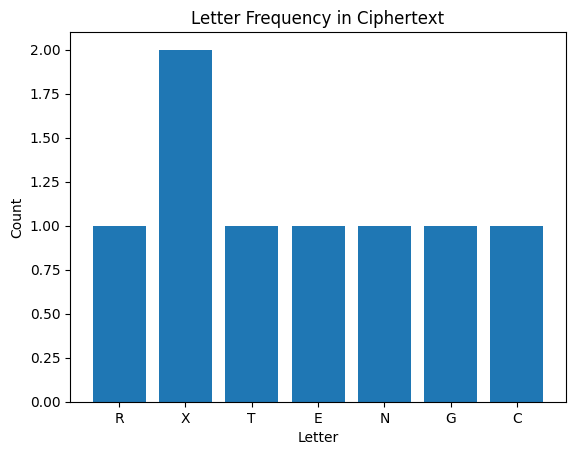

In [9]:
freq = frequency_analysis(cipher)

letters = list(freq.keys())
counts = list(freq.values())

plt.bar(letters, counts)
plt.title("Letter Frequency in Ciphertext")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.show()

## Conclusion

This project demonstrates the implementation of classical encryption algorithms and basic cryptanalysis techniques.
Although these ciphers are not secure for modern use, they help illustrate fundamental cryptographic principles.